<a href="https://colab.research.google.com/github/jayyysiri/carboncast_transformers/blob/main/carboncast_transformer_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CarbonCast with Transformers

by Ben Healy, Sidhant Kumar, and Jay Siri

In [ ]:
import pandas as pd
import numpy as np
import math
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

### Load Datasets

*   Dataset: direction emissions for ISNE
*   Input data: individual_source_production_forecasts (`ISNE_96hr_forecasts_DA.csv`) + 96-hour_weather_forecasts (`ISNE_weather_forecasts.csv`) + historical_carbon_intensity (first 50% of `ISNE_direct_emissions.csv`, next 25% is validation, and last 25% is test, which is same as `ISNE_carbon_direct_Jul_Dec_2021.csv`).
*  Compare this to the CarbonCast results and the ground truth labels(`ISNE_carbon_direct_Jul_Dec_2021.csv`).



In [1]:
individual_source_production_forecasts_df = pd.read_csv('https://raw.githubusercontent.com/carbonfirst/CarbonCast/refs/heads/main/data/ISNE/ISNE_96hr_forecasts_DA.csv')
weather_forecasts_df = pd.read_csv('https://raw.githubusercontent.com/carbonfirst/CarbonCast/refs/heads/main/data/ISNE/ISNE_weather_forecast.csv')
historical_carbon_intensity_df = pd.read_csv('https://raw.githubusercontent.com/carbonfirst/CarbonCast/refs/heads/main/data/ISNE/ISNE_direct_emissions.csv')
ground_truth_df = pd.read_csv('https://raw.githubusercontent.com/carbonfirst/CarbonCast/refs/heads/main/data/ISNE/ISNE_carbon_direct_Jul_Dec_2021.csv')

In [4]:
historical_carbon_intensity_train_df = historical_carbon_intensity_df[:int(len(historical_carbon_intensity_df)/2)]
historical_carbon_intensity_train_df.tail()

,Unnamed: 0,UTC time,carbon_intensity,coal,nat_gas,nuclear,oil,hydro,solar,wind,other
8767,8767,2020-12-31 07:00:00,218.72,17,3735,2112,0,850,0,763,675
8768,8768,2020-12-31 08:00:00,211.57,17,3432,2118,0,874,0,790,680
8769,8769,2020-12-31 09:00:00,213.92,18,3453,2106,0,874,0,718,671
8770,8770,2020-12-31 10:00:00,212.67,19,3491,2119,0,913,0,736,667
8771,8771,2020-12-31 11:00:00,216.74,13,3862,2139,0,893,0,852,678


In [5]:
GROUND_TRUTH_SPLIT_STARTING_INDEX = 13128
historical_carbon_intensity_test_df = historical_carbon_intensity_df[GROUND_TRUTH_SPLIT_STARTING_INDEX:]
historical_carbon_intensity_test_df.head()

,Unnamed: 0,UTC time,carbon_intensity,coal,nat_gas,nuclear,oil,hydro,solar,wind,other
13128,13128,2021-07-01 00:00:00,297.41,105,13552,3301,667,591,10,492,728
13129,13129,2021-07-01 01:00:00,298.21,103,12977,3289,565,356,2,522,734
13130,13130,2021-07-01 02:00:00,294.98,85,11752,3291,545,209,1,523,733
13131,13131,2021-07-01 03:00:00,287.48,81,10353,3292,366,200,1,487,724
13132,13132,2021-07-01 04:00:00,277.62,82,8850,3304,202,198,1,462,732


### Transformer CarbonCast

In [7]:
# -- Constants matching CarbonCast secondTierConfig.json (ISNE) -------------
HIST_HOURS    = 24
HORIZON_HOURS = 96
SLIDING_LEN   = 24       # forecasts are issued once per day at midnight UTC
N_HIST_FEAT   = 6        # carbon_intensity + 5 cyclical datetime features
N_FUTURE_FEAT = 18       # 5 weather + 8 production + 5 cyclical datetime
DEVICE        = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Using device:", DEVICE)

# -- 1) Identify forecast feature columns -----------------------------------
# Production CSV has both 5 weather and 8 production columns; the separate
# weather CSV is redundant for ISNE so we ignore it and source everything
# from individual_source_production_forecasts_df.
WEATHER_COLS = [
    "forecast_avg_wind_speed_wMean",
    "forecast_avg_temperature_wMean",
    "forecast_avg_dewpoint_wMean",
    "forecast_avg_dswrf_wMean",
    "forecast_avg_precipitation_wMean",
]
PRODUCTION_COLS = [
    "avg_coal_production_forecast",
    "avg_hydro_production_forecast",
    "avg_nat_gas_production_forecast",
    "avg_nuclear_production_forecast",
    "avg_oil_production_forecast",
    "avg_other_production_forecast",
    "avg_solar_production_forecast",
    "avg_wind_production_forecast",
]
FORECAST_COLS = WEATHER_COLS + PRODUCTION_COLS  # 13 cols
DATETIME_COLS = ["hour_sin", "hour_cos", "month_sin", "month_cos", "weekend"]


# -- 2) Cyclical datetime features (matches secondTierForecasts.addDateTimeFeatures) --
def cyclical_datetime(times: pd.DatetimeIndex) -> np.ndarray:
    sec_in_year = 365.25 * 24 * 3600
    hour       = np.asarray(times.hour)
    weekday    = np.asarray(times.weekday)
    ts_secs    = np.asarray(times.astype("int64")) // 10**9
    hour_sin   = np.sin(hour * (2 * np.pi / 24))
    hour_cos   = np.cos(hour * (2 * np.pi / 24))
    month_sin  = np.sin(ts_secs * (2 * np.pi / sec_in_year))
    month_cos  = np.cos(ts_secs * (2 * np.pi / sec_in_year))
    weekend    = (weekday >= 5).astype(np.int64)
    return np.stack([hour_sin, hour_cos, month_sin, month_cos, weekend], axis=1).astype(np.float64)


# -- 3) Reshape forecast file into 96-row blocks ----------------------------
def build_forecast_blocks(prod_df: pd.DataFrame) -> dict:
    """Each block is one forecast issuance. Block i covers hours [t0, t0+95]
    where t0 = first timestamp + i*24h. Returns {t0_timestamp: ndarray[96, 13]}."""
    # IMPORTANT: do NOT sort by UTC time. The file is laid out block-by-block
    # (each 96-row block = one forecast issuance); sorting destroys the layout
    # since adjacent blocks have overlapping timestamps.
    df = prod_df.copy()
    df["UTC time"] = pd.to_datetime(df["UTC time"])
    df = df.reset_index(drop=True)
    n_rows = len(df)
    assert n_rows % HORIZON_HOURS == 0, (
        f"Forecast file row count {n_rows} not a multiple of {HORIZON_HOURS}"
    )
    n_blocks = n_rows // HORIZON_HOURS
    blocks = {}
    for i in range(n_blocks):
        start = i * HORIZON_HOURS
        block = df.iloc[start : start + HORIZON_HOURS]
        t0 = block["UTC time"].iloc[0]
        # Sanity: block target times should be t0..t0+95h, hourly.
        expected = pd.date_range(t0, periods=HORIZON_HOURS, freq="h")
        if not (block["UTC time"].values == expected.values).all():
            # Skip malformed blocks rather than crash on data quirks.
            continue
        blocks[t0] = block[FORECAST_COLS].astype(np.float64).values
    return blocks


# -- 4) Sample builder ------------------------------------------------------
def build_samples(forecast_blocks: dict, hist_df: pd.DataFrame, gt_df: pd.DataFrame,
                  start: pd.Timestamp, end: pd.Timestamp):
    """For each forecast issuance t0 in [start, end], assemble:
        hist   shape (24, 6)  - past CI + cyclical datetime
        future shape (96, 18) - forecast covariates + cyclical datetime
        y      shape (96,)    - ground-truth CI for [t0, t0+95]
    Returns lists keyed by t0.
    """
    hist_df = hist_df.copy()
    hist_df["UTC time"] = pd.to_datetime(hist_df["UTC time"])
    hist_series = hist_df.set_index("UTC time")["carbon_intensity"].sort_index()

    gt_df = gt_df.copy()
    gt_df["UTC time"] = pd.to_datetime(gt_df["UTC time"])
    gt_series = gt_df.set_index("UTC time")["carbon_intensity"].sort_index()

    # Use whichever has the target hour available (gt covers Jul-Dec 2021;
    # hist covers full 2020-2021 including the val period).
    truth_series = pd.concat([hist_series, gt_series])
    truth_series = truth_series[~truth_series.index.duplicated(keep="last")].sort_index()

    samples = []
    skipped = 0
    for t0, future_block in sorted(forecast_blocks.items()):
        if t0 < start or t0 > end:
            continue
        hist_start = t0 - pd.Timedelta(hours=HIST_HOURS)
        hist_times = pd.date_range(hist_start, periods=HIST_HOURS, freq="h")
        future_times = pd.date_range(t0, periods=HORIZON_HOURS, freq="h")

        hist_ci = hist_series.reindex(hist_times)
        y_ci    = truth_series.reindex(future_times)
        if hist_ci.isna().any() or y_ci.isna().any():
            skipped += 1
            continue

        hist_dt   = cyclical_datetime(hist_times)                 # (24, 5)
        future_dt = cyclical_datetime(future_times)               # (96, 5)
        hist      = np.concatenate(
            [hist_ci.values.reshape(-1, 1), hist_dt], axis=1
        ).astype(np.float64)                                       # (24, 6)
        future    = np.concatenate(
            [future_block, future_dt], axis=1
        ).astype(np.float64)                                       # (96, 18)
        samples.append({
            "t0":      t0,
            "hist":    hist,
            "future":  future,
            "y":       y_ci.values.astype(np.float64),
        })
    print(f"  built {len(samples)} samples (skipped {skipped} for missing data) "
          f"in window {start.date()} .. {end.date()}")
    return samples


# -- 5) Build train / val / test ---------------------------------------------
print("Building forecast blocks...")
forecast_blocks = build_forecast_blocks(individual_source_production_forecasts_df)
print(f"  {len(forecast_blocks)} forecast blocks (one per midnight issuance)")

print("Building train samples (2020-01-01 -> 2020-12-31)...")
train_samples = build_samples(
    forecast_blocks, historical_carbon_intensity_df, ground_truth_df,
    pd.Timestamp("2020-01-02"), pd.Timestamp("2020-12-31"),
)
print("Building val samples (2021-01-01 -> 2021-06-30)...")
val_samples = build_samples(
    forecast_blocks, historical_carbon_intensity_df, ground_truth_df,
    pd.Timestamp("2021-01-01"), pd.Timestamp("2021-06-30"),
)
print("Building test samples (2021-07-01 -> 2021-12-31)...")
test_samples = build_samples(
    forecast_blocks, historical_carbon_intensity_df, ground_truth_df,
    pd.Timestamp("2021-07-01"), pd.Timestamp("2021-12-31"),
)


Using device: cuda
Building forecast blocks...
  727 forecast blocks (one per midnight issuance)
Building train samples (2020-01-01 -> 2020-12-31)...
  built 365 samples (skipped 0 for missing data) in window 2020-01-02 .. 2020-12-31
Building val samples (2021-01-01 -> 2021-06-30)...
  built 181 samples (skipped 0 for missing data) in window 2021-01-01 .. 2021-06-30
Building test samples (2021-07-01 -> 2021-12-31)...
  built 180 samples (skipped 0 for missing data) in window 2021-07-01 .. 2021-12-31


In [8]:
# Fit StandardScaler on TRAIN ONLY, apply to val/test.
# Two scalers: one for the CI label (so inverse_transform is unambiguous),
# one for each feature block (hist features and future features).

train_hist   = np.stack([s["hist"]   for s in train_samples])   # (N, 24, 6)
train_future = np.stack([s["future"] for s in train_samples])   # (N, 96, 18)
train_y      = np.stack([s["y"]      for s in train_samples])   # (N, 96)

hist_scaler   = StandardScaler().fit(train_hist.reshape(-1, train_hist.shape[-1]))
future_scaler = StandardScaler().fit(train_future.reshape(-1, train_future.shape[-1]))
y_scaler      = StandardScaler().fit(train_y.reshape(-1, 1))

def scale_split(samples):
    if len(samples) == 0:
        return np.empty((0, HIST_HOURS, N_HIST_FEAT)), np.empty((0, HORIZON_HOURS, N_FUTURE_FEAT)), np.empty((0, HORIZON_HOURS))
    H = np.stack([s["hist"]   for s in samples])
    F = np.stack([s["future"] for s in samples])
    Y = np.stack([s["y"]      for s in samples])
    H = hist_scaler.transform(H.reshape(-1, H.shape[-1])).reshape(H.shape)
    F = future_scaler.transform(F.reshape(-1, F.shape[-1])).reshape(F.shape)
    Y = y_scaler.transform(Y.reshape(-1, 1)).reshape(Y.shape)
    return H, F, Y

train_H, train_F, train_Y = scale_split(train_samples)
val_H,   val_F,   val_Y   = scale_split(val_samples)
test_H,  test_F,  test_Y  = scale_split(test_samples)

print(f"train shapes: hist {train_H.shape}, future {train_F.shape}, y {train_Y.shape}")
print(f"val   shapes: hist {val_H.shape},   future {val_F.shape},   y {val_Y.shape}")
print(f"test  shapes: hist {test_H.shape},  future {test_F.shape},  y {test_Y.shape}")
print(f"y_scaler  mean={y_scaler.mean_[0]:.2f}  std={y_scaler.scale_[0]:.2f}")


train shapes: hist (365, 24, 6), future (365, 96, 18), y (365, 96)
val   shapes: hist (181, 24, 6),   future (181, 96, 18),   y (181, 96)
test  shapes: hist (180, 24, 6),  future (180, 96, 18),  y (180, 96)
y_scaler  mean=232.17  std=32.83


In [9]:
class CarbonForecastDataset(Dataset):
    def __init__(self, H, F, Y):
        self.H = torch.tensor(H, dtype=torch.float32)
        self.F = torch.tensor(F, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.H)

    def __getitem__(self, idx):
        return self.H[idx], self.F[idx], self.Y[idx]


train_ds = CarbonForecastDataset(train_H, train_F, train_Y)
val_ds   = CarbonForecastDataset(val_H,   val_F,   val_Y)
test_ds  = CarbonForecastDataset(test_H,  test_F,  test_Y)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Sanity check: one sample's shapes
h0, f0, y0 = train_ds[0]
print(f"One training sample shapes: hist {tuple(h0.shape)}, future {tuple(f0.shape)}, y {tuple(y0.shape)}")


One training sample shapes: hist (24, 6), future (96, 18), y (96,)


In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 256):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class CarbonCastTransformer(nn.Module):
    """Encoder reads 24h CI history (+ datetime). Decoder reads 96h forecast
    covariates (+ datetime). Output: 96 scalar CI predictions."""

    def __init__(self, n_hist=N_HIST_FEAT, n_future=N_FUTURE_FEAT,
                 d_model=64, nhead=4, num_enc=2, num_dec=2,
                 dim_ff=128, dropout=0.1):
        super().__init__()
        self.hist_proj   = nn.Linear(n_hist,   d_model)
        self.future_proj = nn.Linear(n_future, d_model)
        self.pos_hist    = PositionalEncoding(d_model, max_len=HIST_HOURS)
        self.pos_future  = PositionalEncoding(d_model, max_len=HORIZON_HOURS)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec)
        self.out     = nn.Linear(d_model, 1)

    def forward(self, hist, future):
        memory = self.encoder(self.pos_hist(self.hist_proj(hist)))         # (B, 24, d)
        out    = self.decoder(self.pos_future(self.future_proj(future)),
                              memory)                                       # (B, 96, d)
        return self.out(out).squeeze(-1)                                    # (B, 96)


# -------- Training loop with val tracking + early stopping ------------------
torch.manual_seed(0)
model = CarbonCastTransformer().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model has {n_params:,} parameters")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.1, patience=6, min_lr=1e-4
)
criterion = nn.MSELoss()

def run_epoch(loader, train: bool):
    model.train(train)
    total = 0.0
    n = 0
    for hist, future, y in loader:
        hist, future, y = hist.to(DEVICE), future.to(DEVICE), y.to(DEVICE)
        with torch.set_grad_enabled(train):
            pred = model(hist, future)
            loss = criterion(pred, y)
        if train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        total += loss.item() * hist.size(0)
        n     += hist.size(0)
    return total / max(n, 1)

NUM_EPOCHS = 60
PATIENCE   = 10
best_val   = float("inf")
patience_ctr = 0
train_losses = []
val_losses   = []
best_state   = None

for epoch in range(1, NUM_EPOCHS + 1):
    tr  = run_epoch(train_loader, train=True)
    val = run_epoch(val_loader,   train=False)
    train_losses.append(tr)
    val_losses.append(val)
    scheduler.step(val)
    improved = val < best_val - 1e-5
    if improved:
        best_val   = val
        patience_ctr = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_ctr += 1
    print(f"Epoch {epoch:3d}  train MSE={tr:.4f}  val MSE={val:.4f}"
          f"  lr={optimizer.param_groups[0]['lr']:.1e}"
          f"  {'*' if improved else ''}")
    if patience_ctr >= PATIENCE:
        print(f"Early stopping at epoch {epoch} (best val {best_val:.4f})")
        break

if best_state is not None:
    model.load_state_dict(best_state)
print(f"Best val loss: {best_val:.4f}")


Model has 169,153 parameters
Epoch   1  train MSE=0.7174  val MSE=0.4515  lr=1.0e-03  *
Epoch   2  train MSE=0.4078  val MSE=0.3547  lr=1.0e-03  *
Epoch   3  train MSE=0.3685  val MSE=0.5046  lr=1.0e-03  
Epoch   4  train MSE=0.3678  val MSE=0.4891  lr=1.0e-03  
Epoch   5  train MSE=0.3362  val MSE=0.3683  lr=1.0e-03  
Epoch   6  train MSE=0.3009  val MSE=0.4137  lr=1.0e-03  
Epoch   7  train MSE=0.2838  val MSE=0.3351  lr=1.0e-03  *
Epoch   8  train MSE=0.2747  val MSE=0.3578  lr=1.0e-03  
Epoch   9  train MSE=0.2475  val MSE=0.3947  lr=1.0e-03  
Epoch  10  train MSE=0.2460  val MSE=0.3089  lr=1.0e-03  *
Epoch  11  train MSE=0.2320  val MSE=0.3461  lr=1.0e-03  
Epoch  12  train MSE=0.2224  val MSE=0.3728  lr=1.0e-03  
Epoch  13  train MSE=0.2130  val MSE=0.4152  lr=1.0e-03  
Epoch  14  train MSE=0.2085  val MSE=0.2924  lr=1.0e-03  *
Epoch  15  train MSE=0.2091  val MSE=0.3934  lr=1.0e-03  
Epoch  16  train MSE=0.1890  val MSE=0.3058  lr=1.0e-03  
Epoch  17  train MSE=0.1732  val MSE=0

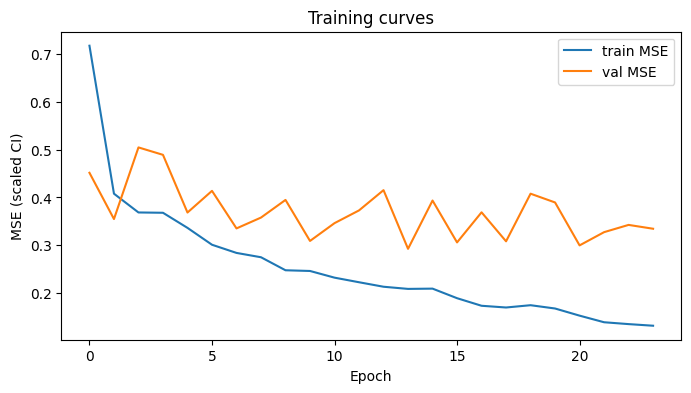

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="train MSE")
ax.plot(val_losses,   label="val MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled CI)")
ax.set_title("Training curves")
ax.legend()
plt.show()


In [12]:
# Inference on the test set — iterate dataloader directly.
model.eval()
all_preds_scaled = []
with torch.no_grad():
    for hist, future, y in test_loader:
        hist, future = hist.to(DEVICE), future.to(DEVICE)
        pred = model(hist, future).cpu().numpy()  # (B, 96)
        all_preds_scaled.append(pred)
preds_scaled = np.concatenate(all_preds_scaled, axis=0)  # (N_test, 96)
print("Test predictions shape:", preds_scaled.shape)

# Inverse-scale using the y_scaler fit on TRAIN labels.
preds = y_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(preds_scaled.shape)
actuals = np.stack([s["y"] for s in test_samples])  # (N_test, 96), already in original scale
print("First test forecast sample (first 8 hours):")
print("  predicted:", preds[0, :8].round(2))
print("  actual:   ", actuals[0, :8].round(2))


Test predictions shape: (180, 96)
First test forecast sample (first 8 hours):
  predicted: [291.16 290.57 289.22 286.34 285.93 282.01 279.21 275.73]
  actual:    [297.41 298.21 294.98 287.48 277.62 266.73 263.64 260.67]


Long results frame: (17280, 6)


,forecast_issued_at,target_time,horizon_hours,predicted_ci,actual_ci,horizon_bucket
0,2021-07-01,2021-07-01 00:00:00,1,291.159302,297.41,1-24h
1,2021-07-01,2021-07-01 01:00:00,2,290.573242,298.21,1-24h
2,2021-07-01,2021-07-01 02:00:00,3,289.216370,294.98,1-24h
3,2021-07-01,2021-07-01 03:00:00,4,286.336853,287.48,1-24h
4,2021-07-01,2021-07-01 04:00:00,5,285.927124,277.62,1-24h
5,2021-07-01,2021-07-01 05:00:00,6,282.011810,266.73,1-24h
6,2021-07-01,2021-07-01 06:00:00,7,279.214264,263.64,1-24h
7,2021-07-01,2021-07-01 07:00:00,8,275.725983,260.67,1-24h


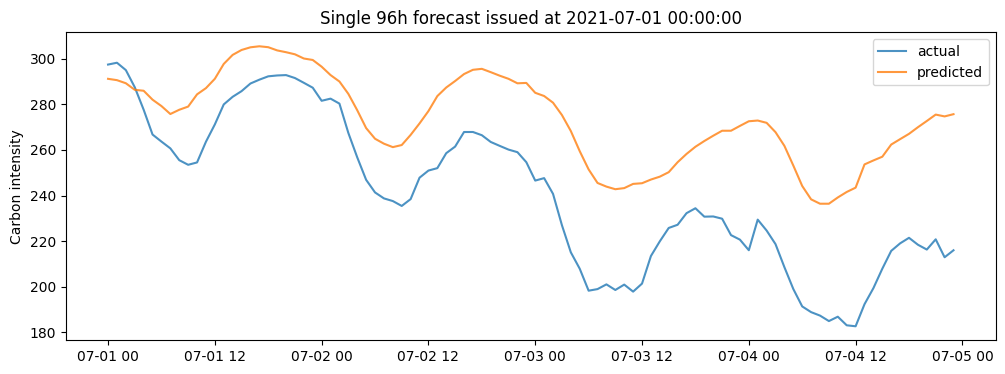

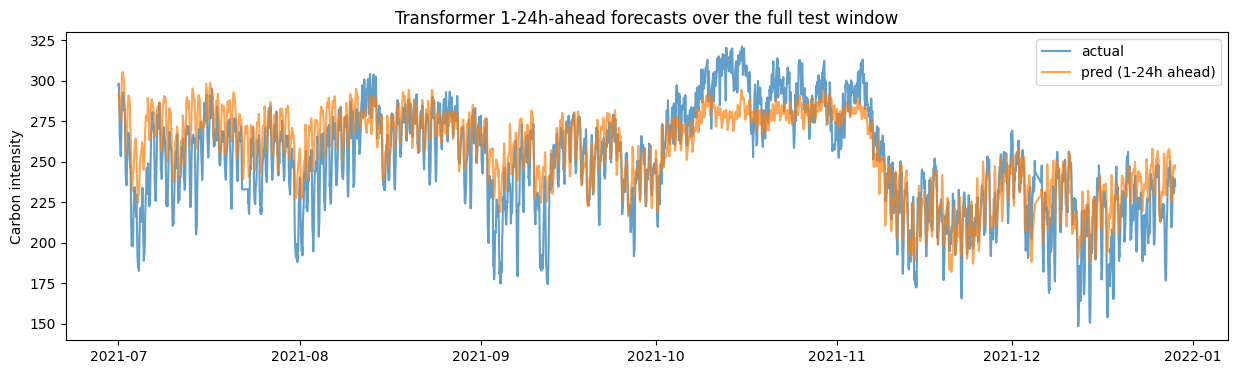

In [13]:
# Build a long-format results frame with one row per
# (forecast_issued_at, target_time, horizon_hours).
records = []
for s_idx, sample in enumerate(test_samples):
    t0 = sample["t0"]
    target_times = pd.date_range(t0, periods=HORIZON_HOURS, freq="h")
    for h in range(HORIZON_HOURS):
        records.append({
            "forecast_issued_at": t0,
            "target_time":        target_times[h],
            "horizon_hours":      h + 1,            # 1..96
            "predicted_ci":       float(preds[s_idx, h]),
            "actual_ci":          float(actuals[s_idx, h]),
        })
results_df = pd.DataFrame.from_records(records)
results_df["horizon_bucket"] = pd.cut(
    results_df["horizon_hours"],
    bins=[0, 24, 48, 72, 96],
    labels=["1-24h", "25-48h", "49-72h", "73-96h"],
)
print("Long results frame:", results_df.shape)
display(results_df.head(8))

# Quick plot: a single forecast issuance, full 96h horizon, vs ground truth.
sample_idx = 0
single = results_df[results_df["forecast_issued_at"] == test_samples[sample_idx]["t0"]]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(single["target_time"], single["actual_ci"],    label="actual",    alpha=0.8)
ax.plot(single["target_time"], single["predicted_ci"], label="predicted", alpha=0.8)
ax.set_title(f"Single 96h forecast issued at {test_samples[sample_idx]['t0']}")
ax.set_ylabel("Carbon intensity")
ax.legend()
plt.show()

# Plot: aggregated 1-24h-ahead predictions (the "next-day" subset) vs actual,
# across the full test window.
near = results_df[results_df["horizon_bucket"] == "1-24h"].copy()
near = near.groupby("target_time", as_index=False).mean(numeric_only=True)
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(near["target_time"], near["actual_ci"],    label="actual",    alpha=0.7)
ax.plot(near["target_time"], near["predicted_ci"], label="pred (1-24h ahead)", alpha=0.7)
ax.set_title("Transformer 1-24h-ahead forecasts over the full test window")
ax.set_ylabel("Carbon intensity")
ax.legend()
plt.show()


In [14]:
ground_truth_df[28:].head(1000)

,Unnamed: 0,UTC time,carbon_intensity,coal,nat_gas,nuclear,oil,hydro,solar,wind,other
28,13156,2021-07-02 04:00:00,256.73,2,6768,3303,1,329,1,260,728
29,13157,2021-07-02 05:00:00,246.88,1,5895,3316,0,310,1,269,718
30,13158,2021-07-02 06:00:00,241.35,0,5551,3301,0,308,1,304,691
31,13159,2021-07-02 07:00:00,238.74,0,5294,3328,0,254,1,315,701
32,13160,2021-07-02 08:00:00,237.57,0,5194,3307,0,231,1,339,692
...,...,...,...,...,...,...,...,...,...,...,...
1023,14151,2021-08-12 15:00:00,295.26,203,11844,3308,180,421,224,64,667
1024,14152,2021-08-12 16:00:00,299.01,245,12648,3313,194,407,297,42,660
1025,14153,2021-08-12 17:00:00,301.07,393,13186,3313,214,631,306,46,663
1026,14154,2021-08-12 18:00:00,298.16,424,13683,3305,248,985,296,59,648


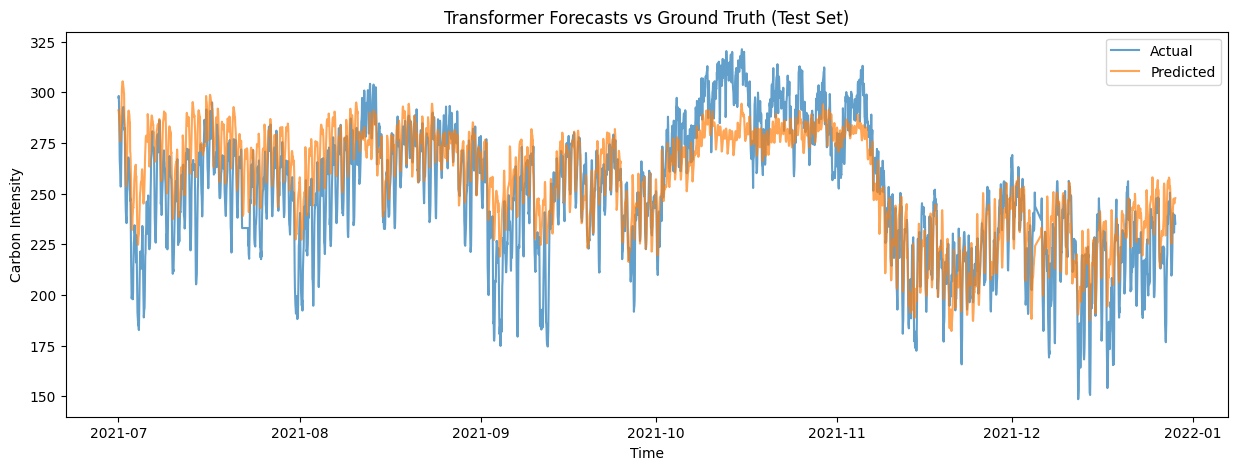

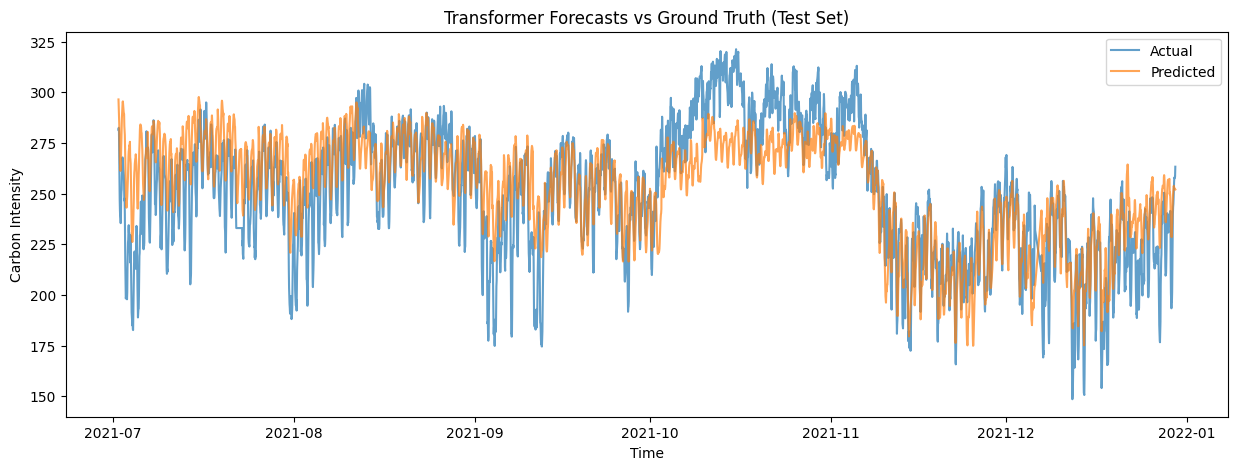

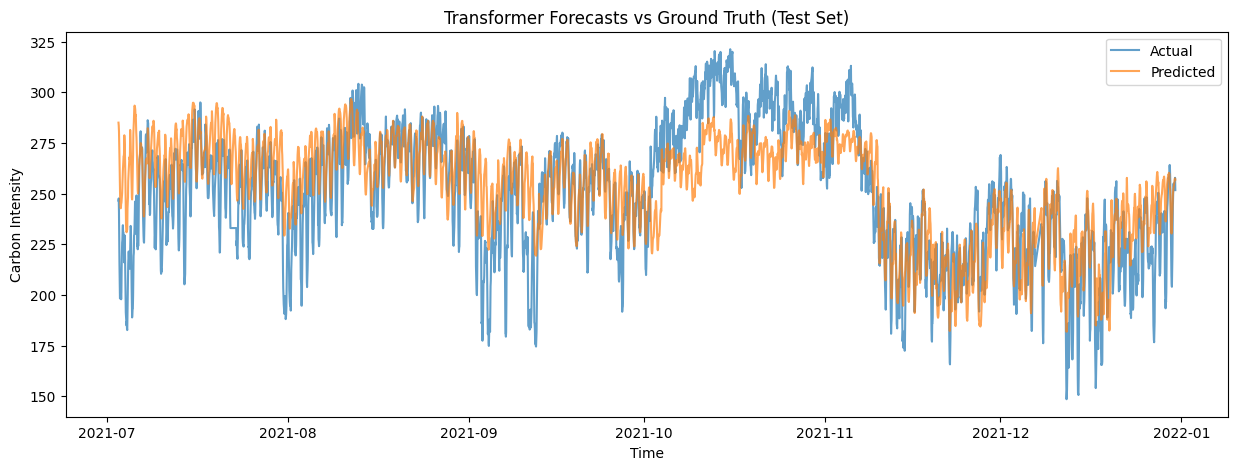

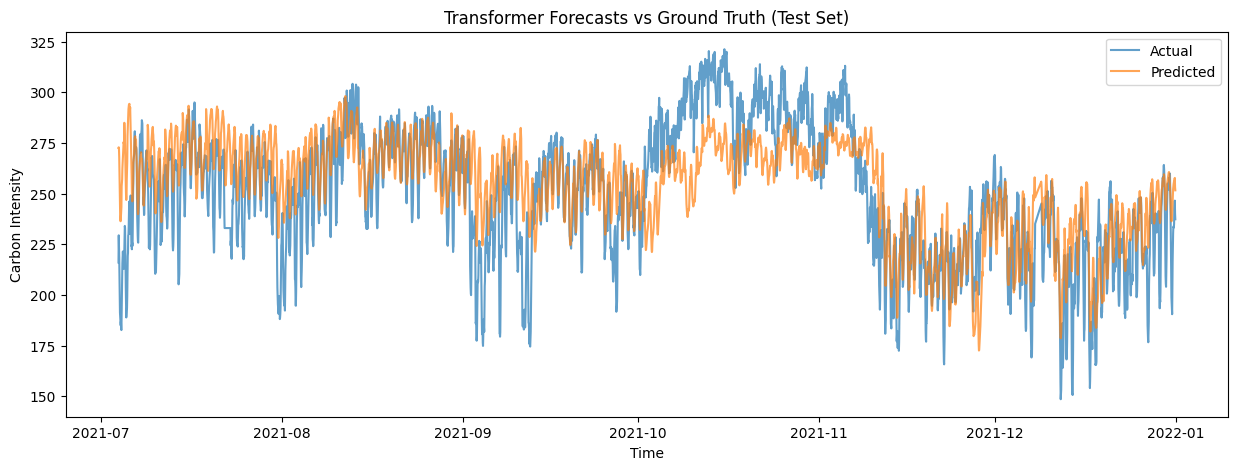

In [16]:
for index in ['1-24h', '25-48h', '49-72h', '73-96h']:
    queried_forecast = results_df[results_df['horizon_bucket'] == index]


    plt.figure(figsize=(15, 5))
    plt.plot(queried_forecast['target_time'], queried_forecast['actual_ci'], label='Actual', alpha=0.7)
    plt.plot(queried_forecast['target_time'], queried_forecast['predicted_ci'], label='Predicted', alpha=0.7)
    plt.title('Transformer Forecasts vs Ground Truth (Test Set)')
    plt.xlabel('Time')
    plt.ylabel('Carbon Intensity')
    plt.legend()
    plt.show()

In [17]:
carbon_cast_forecasts_df = pd.read_csv('https://raw.githubusercontent.com/carbonfirst/CarbonCast/refs/heads/main/data/ISNE/ISNE_carbon_from_src_forecasts_direct_Jul_Dec_2021.csv')
carbon_cast_forecasts_df[24:].head()

,Unnamed: 0,UTC time,actual_carbon_intensity_direct,forecasted_carbon_intensity_direct
24,24,2021-07-02 00:00:00,281.53,299.81
25,25,2021-07-02 01:00:00,282.47,298.02
26,26,2021-07-02 02:00:00,280.29,294.82
27,27,2021-07-02 03:00:00,267.44,291.57
28,28,2021-07-02 04:00:00,256.73,287.17


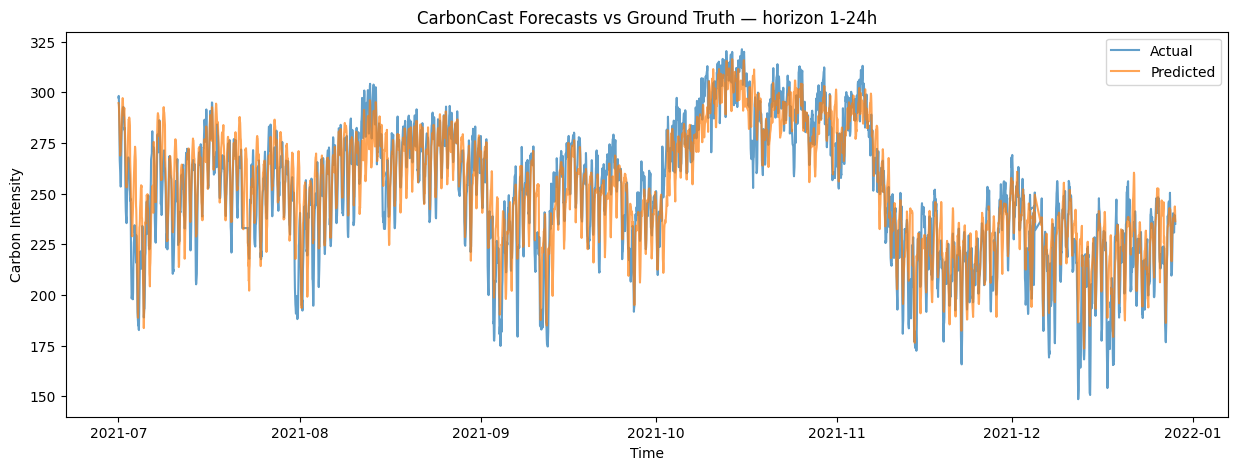

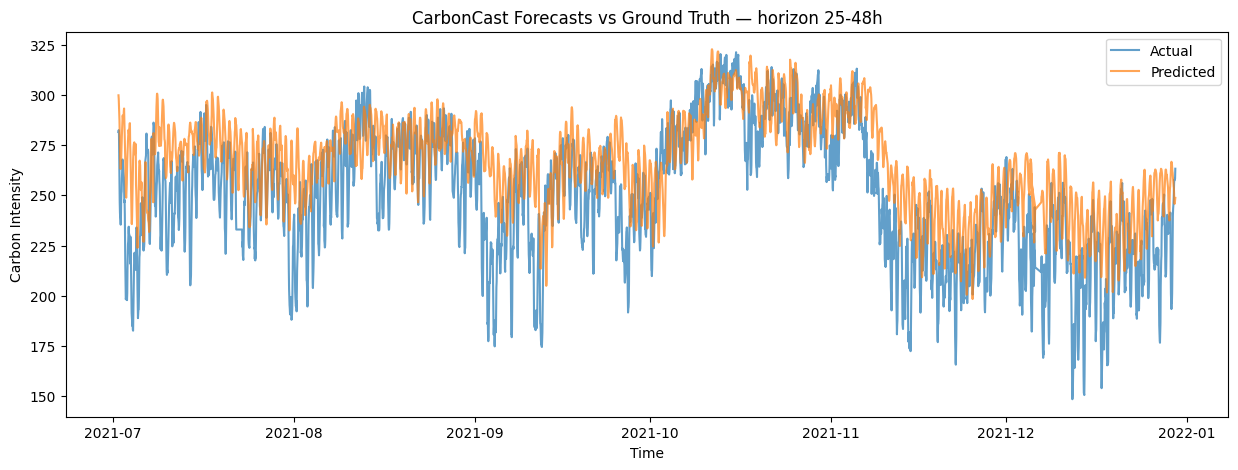

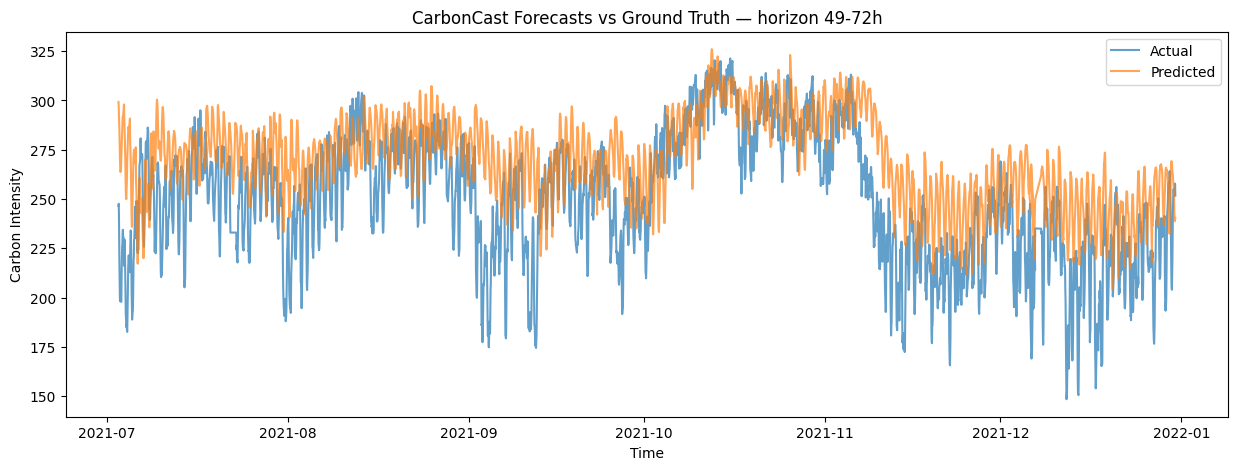

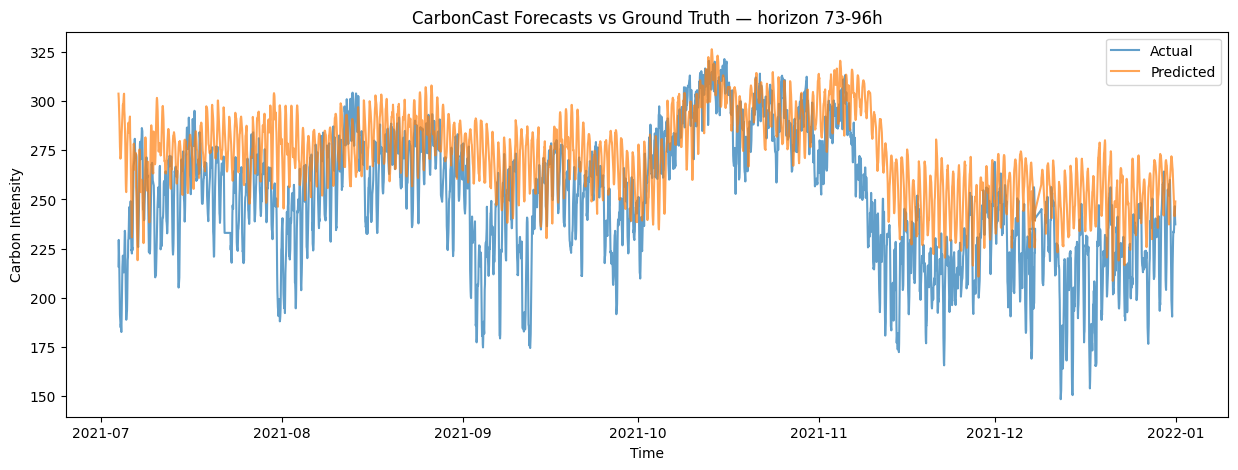

In [18]:
# Add horizon_hours / horizon_bucket to the benchmark frame (96-row blocks).
carbon_cast_forecasts_df = carbon_cast_forecasts_df.reset_index(drop=True)
carbon_cast_forecasts_df['horizon_hours']  = (carbon_cast_forecasts_df.index % 96) + 1
carbon_cast_forecasts_df['horizon_bucket'] = pd.cut(
    carbon_cast_forecasts_df['horizon_hours'],
    bins=[0, 24, 48, 72, 96],
    labels=['1-24h', '25-48h', '49-72h', '73-96h'],
)

for bucket in ['1-24h', '25-48h', '49-72h', '73-96h']:
    sub = carbon_cast_forecasts_df[carbon_cast_forecasts_df['horizon_bucket'] == bucket]

    plt.figure(figsize=(15, 5))
    plt.plot(pd.to_datetime(sub['UTC time']), sub['actual_carbon_intensity_direct'],
             label='Actual', alpha=0.7)
    plt.plot(pd.to_datetime(sub['UTC time']), sub['forecasted_carbon_intensity_direct'],
             label='Predicted', alpha=0.7)
    plt.title(f'CarbonCast Forecasts vs Ground Truth — horizon {bucket}')
    plt.xlabel('Time')
    plt.ylabel('Carbon Intensity')
    plt.legend()
    plt.show()


Transformer per-horizon MAPE (Jul-Dec 2021)
Overall MAPE: 6.67%
  1-24h: 6.20%  (n=4320)
  25-48h: 6.45%  (n=4320)
  49-72h: 6.79%  (n=4320)
  73-96h: 7.23%  (n=4320)

CarbonCast (CNN-LSTM) per-horizon MAPE (Jul-Dec 2021)
Overall MAPE: 9.19%
  1-24h: 4.43%  (n=4344)
  25-48h: 9.46%  (n=4344)
  49-72h: 10.96%  (n=4344)
  73-96h: 11.89%  (n=4344)


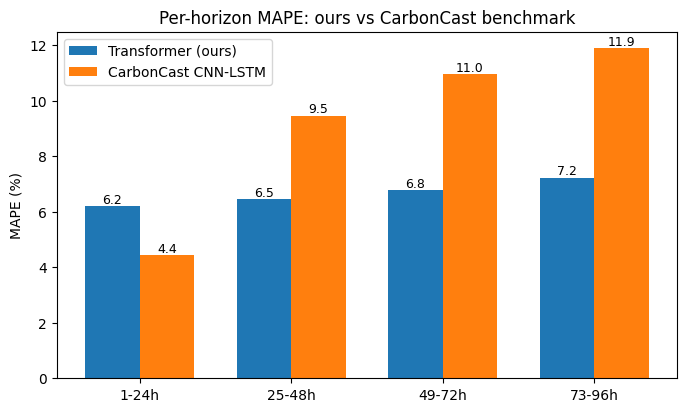


Overall MAPE — transformer: 6.67%  |  CarbonCast: 9.19%


In [19]:
from sklearn.metrics import mean_absolute_percentage_error

def mape(actual, pred):
    return mean_absolute_percentage_error(actual, pred) * 100.0

# -- Our model: per-horizon-bucket MAPE -------------------------------------
print("=" * 60)
print("Transformer per-horizon MAPE (Jul-Dec 2021)")
print("=" * 60)
overall_tx = mape(results_df["actual_ci"], results_df["predicted_ci"])
print(f"Overall MAPE: {overall_tx:.2f}%")
for bucket, sub in results_df.groupby("horizon_bucket", observed=True):
    print(f"  {bucket}: {mape(sub['actual_ci'], sub['predicted_ci']):.2f}%  (n={len(sub)})")

# -- Benchmark file: same per-horizon decomposition -------------------------
# The benchmark CSV has identical 4-duplicate-per-target-hour structure;
# horizon = (row_index_within_block) + 1, where block size is 96.
bench = carbon_cast_forecasts_df.copy()
bench["UTC time"] = pd.to_datetime(bench["UTC time"])
bench = bench.reset_index(drop=True)
bench["block_idx"]      = bench.index // HORIZON_HOURS
bench["horizon_hours"]  = (bench.index % HORIZON_HOURS) + 1
bench["horizon_bucket"] = pd.cut(
    bench["horizon_hours"], bins=[0, 24, 48, 72, 96],
    labels=["1-24h", "25-48h", "49-72h", "73-96h"],
)

print()
print("=" * 60)
print("CarbonCast (CNN-LSTM) per-horizon MAPE (Jul-Dec 2021)")
print("=" * 60)
overall_bench = mape(
    bench["actual_carbon_intensity_direct"],
    bench["forecasted_carbon_intensity_direct"],
)
print(f"Overall MAPE: {overall_bench:.2f}%")
for bucket, sub in bench.groupby("horizon_bucket", observed=True):
    m = mape(sub["actual_carbon_intensity_direct"], sub["forecasted_carbon_intensity_direct"])
    print(f"  {bucket}: {m:.2f}%  (n={len(sub)})")

# -- Side-by-side bar chart -------------------------------------------------
buckets = ["1-24h", "25-48h", "49-72h", "73-96h"]
tx_mapes = [
    mape(
        results_df.loc[results_df["horizon_bucket"] == b, "actual_ci"],
        results_df.loc[results_df["horizon_bucket"] == b, "predicted_ci"],
    )
    for b in buckets
]
bench_mapes = [
    mape(
        bench.loc[bench["horizon_bucket"] == b, "actual_carbon_intensity_direct"],
        bench.loc[bench["horizon_bucket"] == b, "forecasted_carbon_intensity_direct"],
    )
    for b in buckets
]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(buckets))
ax.bar(x - 0.18, tx_mapes,    width=0.36, label="Transformer (ours)")
ax.bar(x + 0.18, bench_mapes, width=0.36, label="CarbonCast CNN-LSTM")
ax.set_xticks(x)
ax.set_xticklabels(buckets)
ax.set_ylabel("MAPE (%)")
ax.set_title("Per-horizon MAPE: ours vs CarbonCast benchmark")
for i, (a, b) in enumerate(zip(tx_mapes, bench_mapes)):
    ax.text(i - 0.18, a, f"{a:.1f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + 0.18, b, f"{b:.1f}", ha="center", va="bottom", fontsize=9)
ax.legend()
plt.show()

print()
print(f"Overall MAPE — transformer: {overall_tx:.2f}%  |  CarbonCast: {overall_bench:.2f}%")


### Deep Ensemble for Uncertainty Quantification (N=5)

We train multiple models with different random initializations. The variance across their predictions provides a measure of epistemic uncertainty.

In [21]:
N_MODELS = 5
ensemble_models = []

for i in range(N_MODELS):
    print(f"\nTraining Model {i+1}/{N_MODELS}...")
    torch.manual_seed(i + 42)  # Different seed for each member
    m = CarbonCastTransformer().to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.MSELoss()

    best_m_val = float('inf')
    best_m_state = None
    p_ctr = 0

    for epoch in range(1, 41): # Reduced epochs for ensemble speed
        m.train()
        for h, f, y in train_loader:
            h, f, y = h.to(DEVICE), f.to(DEVICE), y.to(DEVICE)
            p = m(h, f)
            l = crit(p, y)
            opt.zero_grad()
            l.backward()
            opt.step()

        m.eval()
        val_loss = 0
        with torch.no_grad():
            for h, f, y in val_loader:
                h, f, y = h.to(DEVICE), f.to(DEVICE), y.to(DEVICE)
                val_loss += crit(m(h, f), y).item() * h.size(0)
        val_loss /= len(val_ds)

        if val_loss < best_m_val:
            best_m_val = val_loss
            best_m_state = {k: v.cpu().clone() for k, v in m.state_dict().items()}
            p_ctr = 0
        else:
            p_ctr += 1
        if p_ctr >= 7: break

    m.load_state_dict(best_m_state)
    ensemble_models.append(m)
    print(f"Model {i+1} done. Best Val MSE: {best_m_val:.4f}")


Training Model 1/5...
Model 1 done. Best Val MSE: 0.3831

Training Model 2/5...
Model 2 done. Best Val MSE: 0.3112

Training Model 3/5...
Model 3 done. Best Val MSE: 0.3867

Training Model 4/5...
Model 4 done. Best Val MSE: 0.3613

Training Model 5/5...
Model 5 done. Best Val MSE: 0.3167


In [22]:
# Inference with Ensemble
all_ensemble_preds = [] # List of (N_test, 96) arrays

for m in ensemble_models:
    m.eval()
    preds_list = []
    with torch.no_grad():
        for h, f, y in test_loader:
            h, f = h.to(DEVICE), f.to(DEVICE)
            preds_list.append(m(h, f).cpu().numpy())
    all_ensemble_preds.append(np.concatenate(preds_list, axis=0))

# Stack to (N_MODELS, N_test, 96)
stacked_preds = np.stack(all_ensemble_preds)

# Calculate mean and std in scaled space, then transform to original units
# Note: To be rigorous, we transform the samples then calculate stats,
# as the scaling is linear, Mean(Transformed) == Transformed(Mean).
mean_scaled = stacked_preds.mean(axis=0)
std_scaled = stacked_preds.std(axis=0)

ensemble_mean = y_scaler.inverse_transform(mean_scaled.reshape(-1, 1)).reshape(mean_scaled.shape)
# For std, we only multiply by the scale factor of the StandardScaler
ensemble_std = std_scaled * y_scaler.scale_[0]

print("Ensemble inference complete.")

Ensemble inference complete.


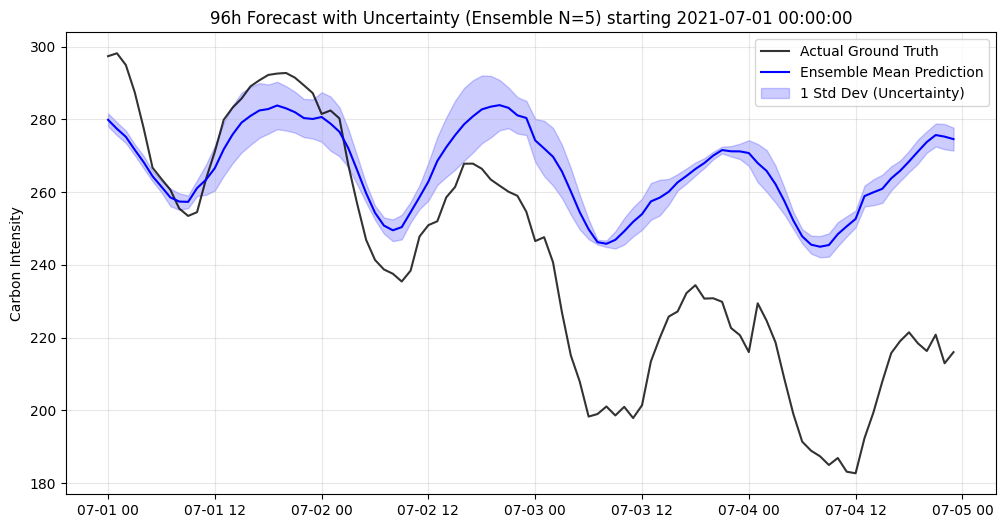

In [24]:
# Plotting a sample forecast with uncertainty
sample_idx = 0
t0 = test_samples[sample_idx]['t0']
times = pd.date_range(t0, periods=HORIZON_HOURS, freq='h')

plt.figure(figsize=(12, 6))
plt.plot(times, actuals[sample_idx], 'k-', label='Actual Ground Truth', alpha=0.8)
plt.plot(times, ensemble_mean[sample_idx], 'b-', label='Ensemble Mean Prediction')

plt.fill_between(times,
                 ensemble_mean[sample_idx] - ensemble_std[sample_idx],
                 ensemble_mean[sample_idx] + ensemble_std[sample_idx],
                 color='b', alpha=0.2, label='1 Std Dev (Uncertainty)')

# plt.fill_between(times,
#                  ensemble_mean[sample_idx] - 2*ensemble_std[sample_idx],
#                  ensemble_mean[sample_idx] + 2*ensemble_std[sample_idx],
#                  color='b', alpha=0.1, label='2 Std Dev')

plt.title(f"96h Forecast with Uncertainty (Ensemble N=5) starting {t0}")
plt.ylabel("Carbon Intensity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

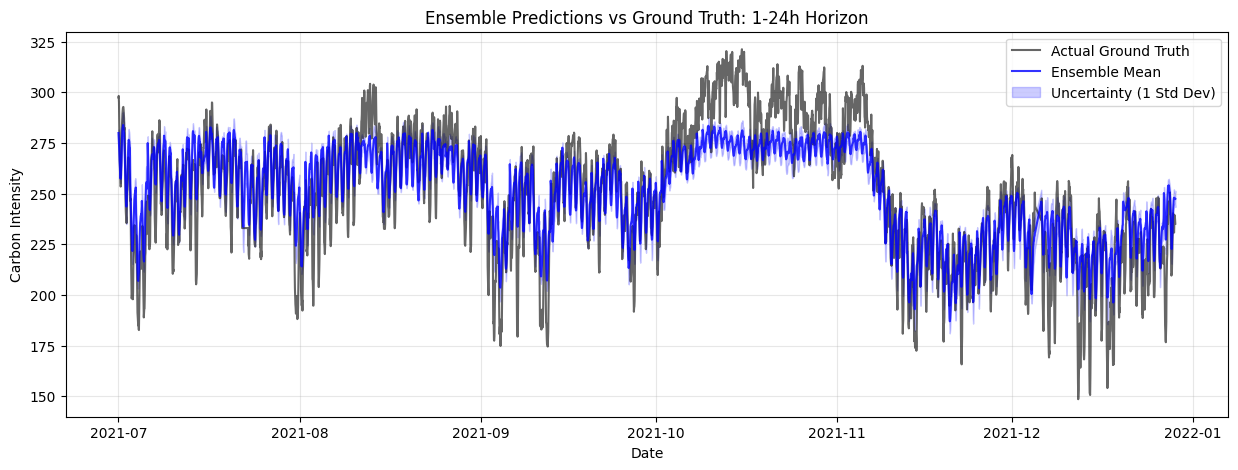

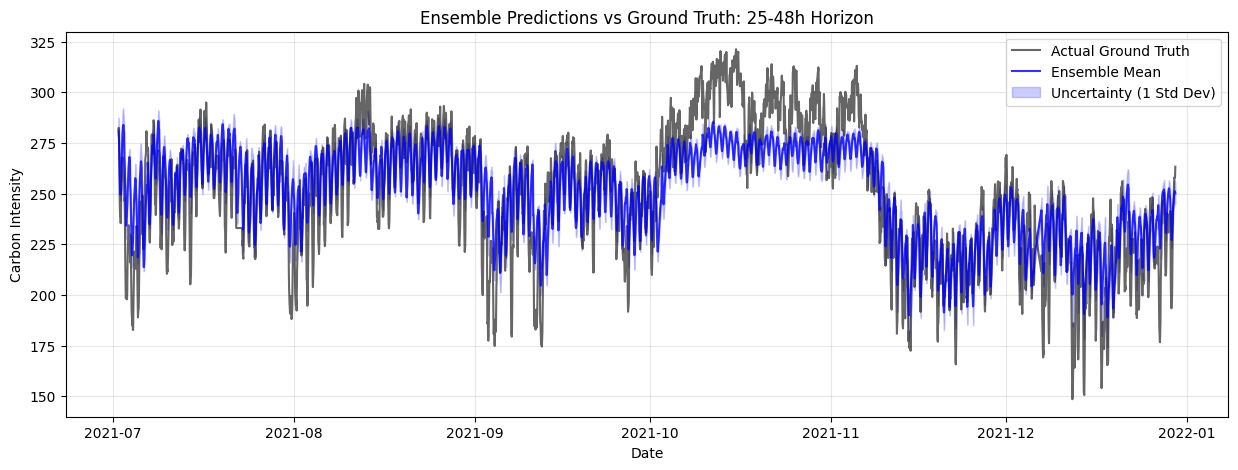

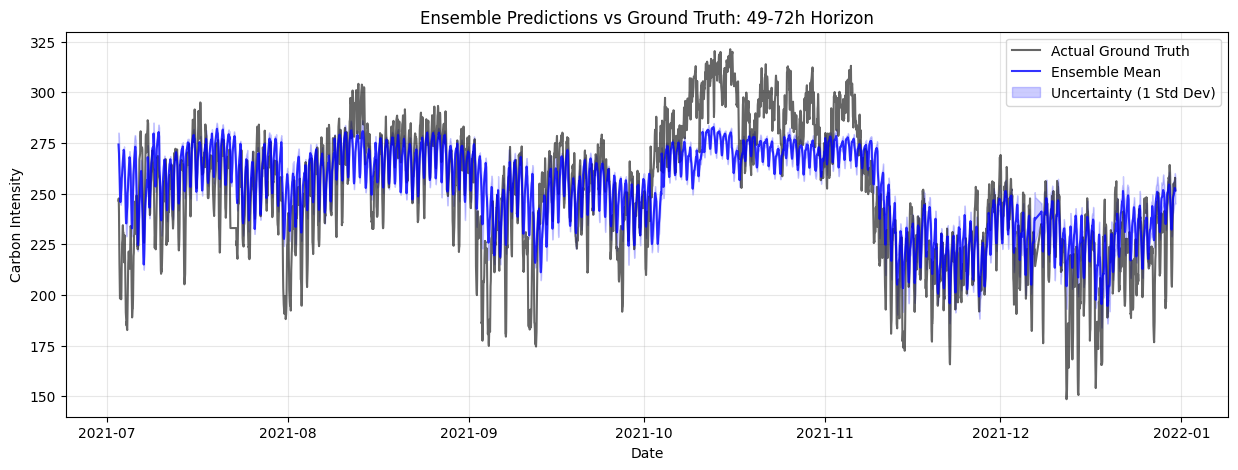

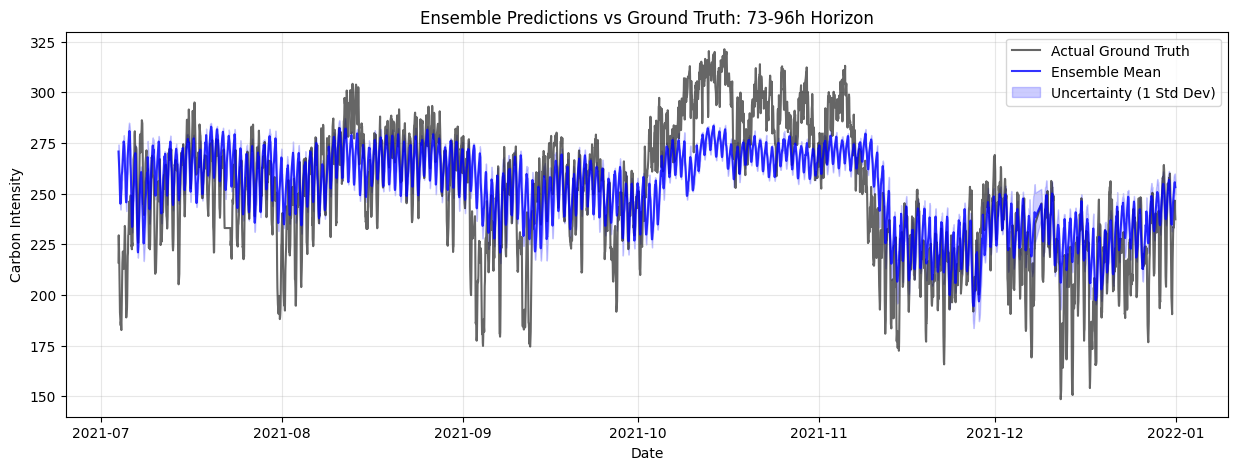

In [27]:
# Aggregate ensemble results for the full test set across horizons
ensemble_records = []
for s_idx, sample in enumerate(test_samples):
    t0 = sample['t0']
    target_times = pd.date_range(t0, periods=HORIZON_HOURS, freq='h')
    for h in range(HORIZON_HOURS):
        ensemble_records.append({
            'target_time': target_times[h],
            'horizon_hours': h + 1,
            'mean_ci': float(ensemble_mean[s_idx, h]),
            'std_ci': float(ensemble_std[s_idx, h]),
            'actual_ci': float(actuals[s_idx, h])
        })

ens_results_df = pd.DataFrame.from_records(ensemble_records)
ens_results_df['horizon_bucket'] = pd.cut(
    ens_results_df['horizon_hours'],
    bins=[0, 24, 48, 72, 96],
    labels=['1-24h', '25-48h', '49-72h', '73-96h']
)

# Plotting per horizon bucket
buckets = ['1-24h', '25-48h', '49-72h', '73-96h']
for bucket in buckets:
    sub = ens_results_df[ens_results_df['horizon_bucket'] == bucket].copy()
    # Average by target_time in case of overlapping forecasts at that horizon
    # Use numeric_only=True to avoid TypeError on categorical columns
    sub = sub.groupby('target_time').mean(numeric_only=True).reset_index()

    plt.figure(figsize=(15, 5))
    plt.plot(sub['target_time'], sub['actual_ci'], 'k-', label='Actual Ground Truth', alpha=0.6)
    plt.plot(sub['target_time'], sub['mean_ci'], 'b-', label='Ensemble Mean', alpha=0.8)

    plt.fill_between(sub['target_time'],
                     sub['mean_ci'] - sub['std_ci'],
                     sub['mean_ci'] + sub['std_ci'],
                     color='b', alpha=0.2, label='Uncertainty (1 Std Dev)')

    plt.title(f'Ensemble Predictions vs Ground Truth: {bucket} Horizon')
    plt.ylabel('Carbon Intensity')
    plt.xlabel('Date')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

### SHAP feature importance

Use `shap.GradientExplainer` to attribute each predicted carbon-intensity
value to the input features. Aggregations:

- **Per-feature** importance: mean(|SHAP|) over output hours, input
  timesteps, and explained samples — answers "which features matter most".
- **Per-feature × forecast-horizon-bucket** importance: same but split by
  output bucket (1-24h, 25-48h, 49-72h, 73-96h) — answers "which features
  carry the model at near vs far horizons".


SHAP arrays: (96, 16, 24, 6) (96, 16, 96, 18)

Historical encoder features (mean |SHAP|):
  carbon_intensity                    0.0052
  month_cos                           0.0046
  month_sin                           0.0021
  weekend                             0.0012
  hour_sin                            0.0000
  hour_cos                            0.0000

Future decoder features (mean |SHAP|):
  avg_nuclear_production_forecast     0.0039
  avg_nat_gas_production_forecast     0.0028
  avg_wind_production_forecast        0.0027
  forecast_avg_dewpoint_wMean         0.0022
  forecast_avg_wind_speed_wMean       0.0021
  avg_solar_production_forecast       0.0021
  forecast_avg_temperature_wMean      0.0020
  weekend                             0.0018
  avg_oil_production_forecast         0.0013
  avg_hydro_production_forecast       0.0011
  month_sin                           0.0010
  forecast_avg_dswrf_wMean            0.0007
  forecast_avg_precipitation_wMean    0.0007
  avg_other_pro

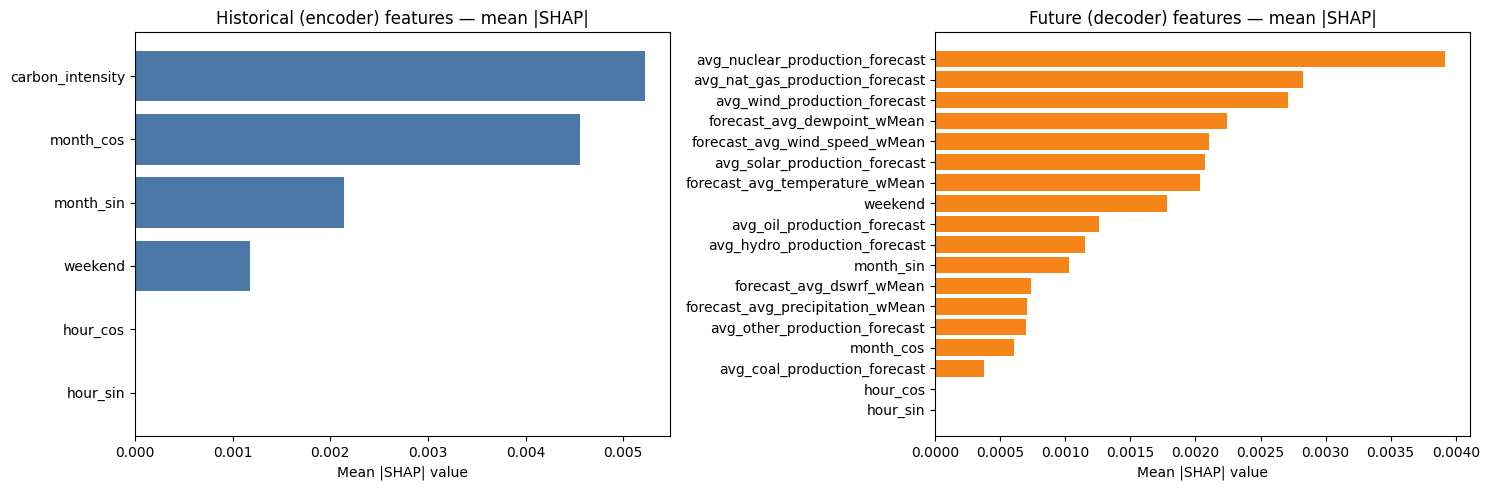

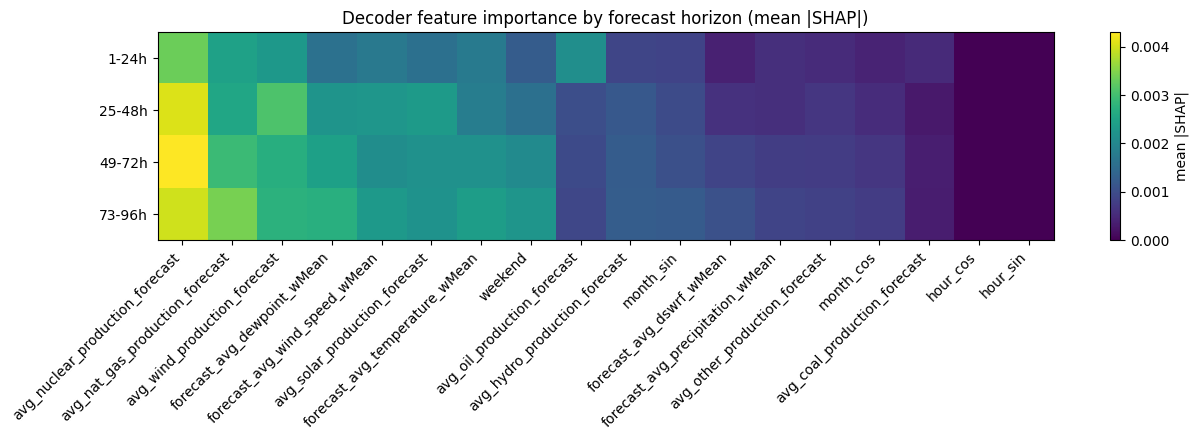

In [20]:
import shap
import numpy as np
import torch
import matplotlib.pyplot as plt

# -- 1) Wrap the model so SHAP can pass (hist, future) as a list of tensors --
class HistFutureWrapper(torch.nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base
    def forward(self, hist, future):
        return self.base(hist, future)

wrapped = HistFutureWrapper(model).to(DEVICE).eval()

# -- 2) Pick background and explanation samples ------------------------------
# Background: a small random subset of train data (SHAP integrates over it).
# Explain: a small subset of test forecasts.
rng = np.random.default_rng(0)
N_BG, N_EX = 32, 16
bg_idx = rng.choice(len(train_H), size=min(N_BG, len(train_H)), replace=False)
ex_idx = rng.choice(len(test_H),  size=min(N_EX, len(test_H)),  replace=False)

bg_hist   = torch.tensor(train_H[bg_idx], dtype=torch.float32, device=DEVICE)
bg_future = torch.tensor(train_F[bg_idx], dtype=torch.float32, device=DEVICE)
ex_hist   = torch.tensor(test_H[ex_idx],  dtype=torch.float32, device=DEVICE)
ex_future = torch.tensor(test_F[ex_idx],  dtype=torch.float32, device=DEVICE)

# -- 3) Run GradientExplainer ------------------------------------------------
explainer = shap.GradientExplainer(wrapped, [bg_hist, bg_future])
# Returns a list with one element per output dim (96): each shape
# [(n_ex, 24, 6), (n_ex, 96, 18)].
shap_values = explainer.shap_values([ex_hist, ex_future])

# Normalise return shape across shap versions: most recent shap returns
# np.ndarrays of shape (n_ex, *input_shape, n_outputs).
def to_per_output_list(sv, n_outputs):
    if isinstance(sv, list) and len(sv) == 2 and isinstance(sv[0], np.ndarray) and sv[0].ndim == 4:
        # shap >=0.45: list[input] of (n_ex, T, F, n_outputs)
        per = [[sv[0][..., k], sv[1][..., k]] for k in range(n_outputs)]
        return per
    if isinstance(sv, list) and len(sv) == n_outputs:
        # older shap: list[output] of [hist_arr, future_arr]
        return sv
    raise ValueError(f"Unexpected shap return shape: type={type(sv)}, "
                     f"first={type(sv[0]) if isinstance(sv, list) else None}")

per_output = to_per_output_list(shap_values, HORIZON_HOURS)

# Stack into arrays: shape (n_outputs, n_ex, T_in, F)
shap_hist   = np.stack([per_output[k][0] for k in range(HORIZON_HOURS)], axis=0)  # (96, N_EX, 24, 6)
shap_future = np.stack([per_output[k][1] for k in range(HORIZON_HOURS)], axis=0)  # (96, N_EX, 96, 18)
print("SHAP arrays:", shap_hist.shape, shap_future.shape)

# -- 4) Per-feature importance (mean|SHAP|) ----------------------------------
HIST_FEATURE_NAMES   = ["carbon_intensity"] + DATETIME_COLS
FUTURE_FEATURE_NAMES = FORECAST_COLS + DATETIME_COLS

imp_hist   = np.abs(shap_hist).mean(axis=(0, 1, 2))     # (6,)
imp_future = np.abs(shap_future).mean(axis=(0, 1, 2))   # (18,)

print("\nHistorical encoder features (mean |SHAP|):")
for name, val in sorted(zip(HIST_FEATURE_NAMES, imp_hist), key=lambda x: -x[1]):
    print(f"  {name:35s} {val:.4f}")

print("\nFuture decoder features (mean |SHAP|):")
for name, val in sorted(zip(FUTURE_FEATURE_NAMES, imp_future), key=lambda x: -x[1]):
    print(f"  {name:35s} {val:.4f}")

# -- 5) Per-feature × horizon-bucket importance ------------------------------
buckets = {"1-24h": (0, 24), "25-48h": (24, 48), "49-72h": (48, 72), "73-96h": (72, 96)}
hist_by_bucket   = {b: np.abs(shap_hist[lo:hi]).mean(axis=(0, 1, 2))   for b, (lo, hi) in buckets.items()}
future_by_bucket = {b: np.abs(shap_future[lo:hi]).mean(axis=(0, 1, 2)) for b, (lo, hi) in buckets.items()}

# -- 6) Bar charts ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
hist_order   = np.argsort(imp_hist)[::-1]
future_order = np.argsort(imp_future)[::-1]

axes[0].barh([HIST_FEATURE_NAMES[i] for i in hist_order][::-1],
             imp_hist[hist_order][::-1], color="#4c78a8")
axes[0].set_title("Historical (encoder) features — mean |SHAP|")
axes[0].set_xlabel("Mean |SHAP| value")

axes[1].barh([FUTURE_FEATURE_NAMES[i] for i in future_order][::-1],
             imp_future[future_order][::-1], color="#f58518")
axes[1].set_title("Future (decoder) features — mean |SHAP|")
axes[1].set_xlabel("Mean |SHAP| value")

plt.tight_layout()
plt.show()

# -- 7) Heatmap: future features × horizon bucket ----------------------------
mat = np.stack([future_by_bucket[b] for b in buckets], axis=0)  # (4, 18)
# sort features by overall importance for readability
mat = mat[:, future_order]
fig, ax = plt.subplots(figsize=(13, 4.5))
im = ax.imshow(mat, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(future_order)))
ax.set_xticklabels([FUTURE_FEATURE_NAMES[i] for i in future_order], rotation=45, ha="right")
ax.set_yticks(range(len(buckets)))
ax.set_yticklabels(list(buckets.keys()))
ax.set_title("Decoder feature importance by forecast horizon (mean |SHAP|)")
fig.colorbar(im, ax=ax, label="mean |SHAP|")
plt.tight_layout()
plt.show()
